In [4]:
from astropy import units as u
import numpy as np
from matplotlib import pyplot as plt
import importlib

Checking the value of the Ishikawa & Krucker (2019) EM ranges for their AR once converted to the area used in this work:

In [25]:
#Ishikawa (2019) hot plasma EM >5MK per orbit (ranges)

ex_area = (360*u.arcsec)**2
nuarea = (150*u.arcsec)**2*np.pi
print('Area ratio: ', ex_area/nuarea)
print('Area Difference Factor: ', 1/(ex_area/nuarea))

conversion = ((750*u.km)/(1*u.arcsec))**2
print(conversion)

#total area factor
taf = (ex_area*conversion).decompose()
print(taf)

orbits = [[6.3e45, 16e45]*(u.cm)**(-3), [0.033e45, 11e45]*(u.cm)**(-3), [6.6e45, 17e45]*(u.cm)**(-3), [6.3e45, 16e45]*(u.cm)**(-3)]
print('')

for oo in orbits:
    print((oo[0]/taf).decompose().to(1/(u.cm**5)), 
          (oo[1]/taf).decompose().to(1/(u.cm**5)))


print('')

full_temp = [4.8e48, 8.7e48]*(u.cm)**(-3)
print((full_temp[0]/taf).decompose().to(1/(u.cm**5)), 
      (full_temp[1]/taf).decompose().to(1/(u.cm**5)))

Area ratio:  1.8334649444186342
Area Difference Factor:  0.545415391248228
562500.0 km2 / arcsec2
7.29e+16 m2

8.641975308641975e+24 1 / cm5 2.194787379972565e+25 1 / cm5
4.526748971193416e+22 1 / cm5 1.5089163237311385e+25 1 / cm5
9.053497942386832e+24 1 / cm5 2.3319615912208508e+25 1 / cm5
8.641975308641975e+24 1 / cm5 2.194787379972565e+25 1 / cm5

6.584362139917695e+27 1 / cm5 1.1934156378600824e+28 1 / cm5


Checking whether the applied DEM rescaling factors across all regions are of similar magnitude as they were in the prior study (1<r<2):

1.139599651020892 1.7357767987345651


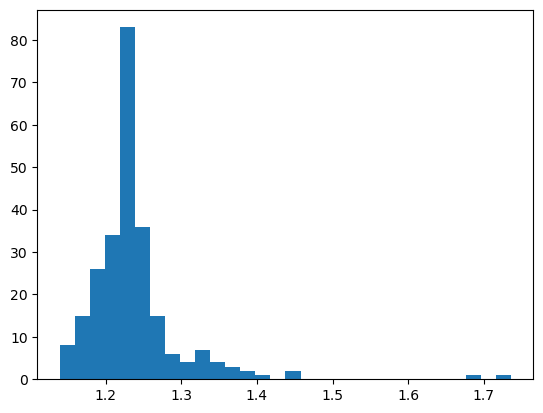

In [41]:
import pickle

path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import all_nu_analysis as ana

with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
filelist = ana.get_same_region_file_lists(samesames, all_targets, get_agelists=False, noxrt=False)

mnrats=[]
for rl in filelist:
    for f_ in rl:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        mnrats.append(data['mnrat'])

plt.hist(mnrats, bins=30)
print(np.min(mnrats), np.max(mnrats))

Examining all keys in the all_targets dictionaries, to make a reference (written notes) as to what each one is for.

In [49]:
klists=[]
for kk in all_targets.keys():
    klists.append(list(all_targets[kk].keys()))

common_keys = list(set(klists[0]).intersection(*klists[1:]))

for kk in all_targets.keys():

    # if 'gauss_stats' in list(all_targets[kk].keys()):
    #     print(all_targets[kk]['method'], kk)

    
    #if all_targets[kk]['method'] == 'input':
    print(kk, all_targets[kk]['method'])
    for key in list(all_targets[kk].keys()):
        if key not in common_keys:
            if key not in ['Ghost_Ray_Rate_B','Ghost_Ray_Rate_A', 'Region Coordinates', 'region_stats', 'gauss_stats']:
                print(key)
                #print('')
        
        #if 'obvious ghost rays' not in list(all_targets[kk].keys()):
        #    print(kk, all_targets[kk]['method'])
    print('')

01-nov-14_1 input
nushift
regdicts

01-nov-14_2 input

11-dec-14 fit
nushift
regdicts

19-feb-16 fit
prepped_aia

22-apr-16_1 fit

22-apr-16_2 fit
prepped_aia

26-jul-16_1 input
nushift
regdicts

27-jul-16_1 input
nushift
regdicts

26-jul-16_2 input
nushift
regdicts

10-oct-17 input
nushift
regdicts

29-may-18_1 fit
prepped_aia

29-may-18_2 input
nushift
regdicts

07-sep-18 fit
nushift
regdicts

09-sep-18 fit
prepped_aia

10-sep-18 fit
prepped_aia

12-apr-19 fit
prepped_aia

13-apr-19 fit
prepped_aia

29-jan-20 fit
prepped_aia

06-jun-20 fit
prepped_aia

07-jun-20 fit
prepped_aia

08-jun-20 fit
prepped_aia

09-jun-20 fit
prepped_aia

08-jan-21 fit
prepped_aia

14-jan-21 input
nushift
regdicts

20-jan-21 fit
prepped_aia

29-apr-21 fit
prepped_aia

03-may-21_1 fit
prepped_aia

03-may-21_2 fit
prepped_aia

30-jul-21_1 double
prepped_aia

30-jul-21_2 fit
prepped_aia

17-nov-21_1 fit
nushift
regdicts

19-nov-21 input
nushift
regdicts

20-nov-21 input
nushift
regdicts

22-nov-21_1 fit
nushif

In [29]:
common_keys

['ghost_ray_flag',
 'total duration',
 'total livetime',
 'HARP',
 'directories',
 'method',
 'hale_class',
 'orbit durations',
 'NOAA_ARID',
 'goes_satellite',
 'Region Ages',
 'notes',
 'datapaths',
 'HARP params',
 'working_dir',
 'obsids',
 'sub_keys',
 'res_file_dict(s)',
 'obvious ghost rays',
 'per_region_all_time_intervals',
 'per_region_quiet_time_intervals',
 'loc']

In [50]:
all_targets['22-apr-16_2']

{'NOAA_ARID': ['AR12529'],
 'HARP': [6483],
 'datapaths': ['/Users/jmdunca2/nustar//apr-2016/20101017001/',
  '/Users/jmdunca2/nustar//apr-2016/20101018001/',
  '/Users/jmdunca2/nustar//apr-2016/20101019001/',
  '/Users/jmdunca2/nustar//apr-2016/20101020001/'],
 'obsids': ['20101017001', '20101018001', '20101019001', '20101020001'],
 'ghost_ray_flag': False,
 'obvious ghost rays': [False, False, False, False],
 'working_dir': '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_22apr16_2/',
 'loc': ['limb'],
 'hale_class': ['beta'],
 'method': 'fit',
 'notes': 'Over-Limb AR - dramatic change in brightness in last two orbits due to later brightening. TIS finishes for all 4.',
 'goes_satellite': 15,
 'orbit durations': [<Quantity 50.39999998 min>,
  <Quantity 60.28333333 min>,
  <Quantity 40.46666667 min>,
  <Quantity 60.26666667 min>],
 'total duration': <Quantity 211.41666665 min>,
 'total livetime': <Quantity 12.46831035 min>,
 'gauss_stats': [([], 3), ([], 3), ([], 3), ([], 3)],
 'direct